# Demanda en urgencias del Gran Concepción: ETL y análisis descriptivo (avance)

**Objetivo del notebook:** producir el material numérico y gráfico de la presentación de avance (15-oct-2026): descripción de los datos, problemas de calidad, estadística descriptiva de la variable objetivo, figuras y baselines para la propuesta metodológica.

**Fuente:** Departamento de Estadísticas e Información de Salud (DEIS), MINSAL. *Atenciones de Urgencia*, archivos anuales 2023–2026 (repositorio DEIS, catálogo en datos.gob.cl) y diccionario de datos.

> **El EDA usa TODA la data disponible: 2023 a 2026 (hasta la última semana con carga completa, 27-09-2026).** Todas las tablas y figuras descriptivas cubren los cuatro años; 2026 es un año parcial (semanas ISO 1–39) y así se rotula. La semana del 28-09 al 04-10-2026 se descarta porque el DEIS aún la tenía a medio cargar (el 04-10 solo habían informado 13 de 26 establecimientos; ver sección 6). El *test* es un tramo cronológico final que **solo se aparta para el modelado** (baselines y modelos no lo usan); no condiciona el EDA.

> **Versión V2:** reorganiza el código de `Trabajo.ipynb` (nombres más claros, pasos separados, comentarios) **y cambia el diseño temporal**: `Trabajo.ipynb` hace el EDA solo con 2023–2025 y reserva todo 2026 como test, por lo que sus resultados ya no coinciden con los de este notebook.

**Diseño temporal (por validar con los profesores)**

| Conjunto | Semanas (lunes–domingo, ISO) | Uso |
|---|---|---|
| **EDA (toda la data)** | 02-01-2023 a 27-09-2026 (195 semanas; años ISO 2023–2025 completos y 2026 hasta la semana 39) | Todas las tablas y figuras descriptivas |
| Entrenamiento y validación | 02-01-2023 a 05-07-2026 (183 semanas) | Baselines y futuros modelos, con validación de origen móvil (`TimeSeriesSplit`) |
| Test reservado | 06-07-2026 a 27-09-2026 (12 semanas) | No entra en baselines ni en la selección de modelos; se usa una sola vez al final |

Limitación declarada: en clase se describe solo el *train* antes de modelar. Aquí el EDA incluye también las 12 semanas del test; no ajusta ningún modelo, pero lo que se observe puede influir en la elección de variables. Queda como pregunta para los profesores (sección 18).

**Mapa del notebook → bloques de la presentación**

| Sección | Bloque |
|---|---|
| 1–3. Parámetros, descarga, ETL | 2. Datos (fuentes, integración, filtro) |
| 4. Tabla 1 | 2. Datos (unidad, n.º obs., período, variables) |
| 5–7. Tabla 2 y anexo de anomalías | 2. Datos (calidad) |
| 6, 8. Serie semanal y Tabla 3 | 3. Descriptivo (estadísticas del objetivo) |
| 9–12. Figuras 1 a 4 | 3. Descriptivo (gráficos) |
| 13–14. Anexos regional y día de la semana | 3. Hallazgos / anexo |
| 15. Tabla 4 | 3–4. Hallazgos que orientan el modelamiento |
| 16. Tabla 5 | 4. Propuesta metodológica (métricas, validación) |
| 18. Preguntas | 5. Próximos pasos / preguntas a los profesores |

**Variables clave que se repiten en el notebook**

| Variable | Qué contiene |
|---|---|
| `df` | Filas diarias de las 7 comunas, 2023–2026 (una fila = establecimiento × día × causa) |
| `eda` | Igual a `df`: el EDA usa toda la data |
| `info_est` | Nombre, tipo y comuna de cada establecimiento |
| `sem` | Serie semanal por establecimiento, con la columna `conjunto` (`entrenamiento` / `test`) |
| `sem_eda` | `sem` completo (todas las semanas, incluido el tramo de test) de los establecimientos con cobertura |
| `Y` | Matriz establecimiento × semana con la variable objetivo (atenciones) sobre todo el período; base de anomalías y figuras |
| `Y_modelo` | `Y` sin las semanas de test: es la única base de los baselines y de los modelos |
| `total_semanal` | Suma de Gran Concepción por semana (índice = lunes de la semana), todo el período |

**Aviso:** las celdas "Interpretación (grupo)" quedan pendientes a propósito; las interpretaciones las redacta el grupo.


## 1. Configuración y parámetros

In [1]:
# Librerías estándar
import hashlib
import urllib.request
from datetime import datetime
from pathlib import Path

# Análisis y gráficos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# Métricas, validación temporal y autocorrelación
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import acf

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Rutas (relativas a la carpeta del repositorio) ----
DIR_RAW = Path("data/raw")
DIR_PROC = Path("data/processed")
DIR_FIG = Path("resultados/figuras")
DIR_TAB = Path("resultados/tablas")
for carpeta in (DIR_RAW, DIR_PROC, DIR_FIG, DIR_TAB):
    carpeta.mkdir(parents=True, exist_ok=True)

# ---- Fuentes de datos ----
ANIOS = [2023, 2024, 2025, 2026]
URL_ANIO = "https://repositoriodeis.minsal.cl/SistemaAtencionesUrgencia/AtencionesUrgencia{}.zip"
URL_DICC = ("https://datos.gob.cl/dataset/be2a922f-8ea4-4ebc-8828-0c713b702cd2/resource/"
            "79c05b22-391b-4dbd-a362-ba088fecabab/download/diccionario-de-datos-atencionesurgencia.xlsx")
RUTA_DICC = DIR_RAW / "diccionario-de-datos-atencionesurgencia.xlsx"
FORZAR_ETL = False   # True = volver a leer los zips aunque existan los parquet

# ---- Diseño temporal: semanas lunes–domingo ----
# EDA = TODA la data (2023-01-01 hasta la última semana completa de 2026). El test solo se aparta para el modelado.
ANIOS_EDA = [2023, 2024, 2025, 2026]   # años ISO del EDA (2026 es parcial: hasta la última semana completa)
# Lunes desde el que se reserva el test (12 semanas hasta el 27-09-2026). Se fija por fecha, no como "últimas N",
# porque el DEIS actualiza 2026 a diario y el test no debe correrse en cada ejecución.
INICIO_TEST_SEMANA = pd.Timestamp("2026-07-06")
assert INICIO_TEST_SEMANA.weekday() == 0, "el test debe empezar un lunes"
# Rezago de reporte: las semanas finales pueden estar a medio cargar. Se descartan si < este % de los establecimiento-días informó.
COBERTURA_MIN_SEMANA = 0.95

# ---- Alcance (por validar con los profesores) ----
# Comunas del área metropolitana núcleo (se filtra por código, no por nombre)
COMUNAS = {8101: "Concepción", 8102: "Coronel", 8103: "Chiguayante", 8107: "Penco",
           8108: "San Pedro de la Paz", 8110: "Talcahuano", 8112: "Hualpén"}
# Candidatas fuera por ahora: 8104 Florida, 8105 Hualqui, 8106 Lota, 8109 Santa Juana, 8111 Tomé.

# Establecimientos que cambiaron de código entre años (código antiguo → actual)
ID_EQUIVALENTE = {"19-912": "201018"}   # SAR Los Cerros: 19-912 en 2023, 201018 desde 2024

# Causas: el archivo mezcla totales, subtotales y detalle, por eso se elige una sola
ID_OBJETIVO = 1        # SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA (provisional, por validar)
ID_RESP = 2            # TOTAL CAUSAS SISTEMA RESPIRATORIO
HORIZONTE = 1          # semanas hacia adelante (por validar)

# ---- Columnas del archivo ----
BANDAS = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]   # edades; suman Total
COLUMNAS = ["IdEstablecimiento", "NEstablecimiento", "IdCausa", "GlosaCausa", "Total", *BANDAS, "fecha", "semana",
            "GLOSATIPOESTABLECIMIENTO", "GLOSATIPOATENCION", "GlosaTipoCampana", "CodigoRegion", "NombreRegion",
            "CodigoDependencia", "NombreDependencia", "CodigoComuna", "NombreComuna"]

# ---- Estilo de los gráficos ----
FUENTE = "Fuente: DEIS-MINSAL, Atenciones de Urgencia (repositorio DEIS / datos.gob.cl). Elaboración propia."

# Paleta UdeC (laboratorio del curso); un color fijo por tipo y por año
NAVY, GREY, ORANGE, RED, TEAL = "#223c6a", "#a0a0a0", "#e69b0a", "#d21428", "#00a896"
COLOR_TIPO = {"Hospital": NAVY, "SAR": TEAL, "SAPU": ORANGE}
COLOR_ANIO = {2023: NAVY, 2024: TEAL, 2025: ORANGE, 2026: RED}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
SEMANA_MES = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48]   # semana ISO aprox. del día 1 de cada mes

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e6e6", "axes.edgecolor": "#bbbbbb"})
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})


# ---- Funciones auxiliares (formato y gráficos) ----
def miles(x, _=None):
    """Formato de miles con punto (es-CL)."""
    return f"{x:,.0f}".replace(",", ".")


def corto(texto, n):
    """Recorta un texto a n caracteres, agregando '…' si se cortó."""
    return texto if len(texto) <= n else texto[:n].rstrip() + "…"


def eje_semanas(ax):
    """Eje x = semana ISO (1–52) rotulado con meses aproximados."""
    ax.set_xticks(SEMANA_MES, MESES)
    ax.set_xlim(0.5, 52.5)


def sombrear_invierno(ax):
    """Marca con una banda gris las semanas de invierno (jun–ago)."""
    ax.axvspan(22, 35.5, color=GREY, alpha=0.15, lw=0)
    ax.text(28.75, 0.98, "Invierno (jun–ago)", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8, color="#555555")


def rotulo_anio(anio, tabla):
    """Año como texto; si el año ISO no está completo se agrega '(parcial, sem. 1–N)'."""
    ultima = int(tabla.loc[tabla["anio_iso"] == anio, "semana_iso"].max())
    return str(anio) if ultima >= 52 else f"{anio} (parcial, sem. 1–{ultima})"


def graficar_lineas_por_anio(ax, tabla, columna):
    """Una línea por año ISO (x = semana del año) con el año rotulado al final de la línea."""
    for anio in ANIOS_EDA:
        serie = tabla[tabla["anio_iso"] == anio].set_index("semana_iso")[columna]
        rotulo = rotulo_anio(anio, tabla)
        ax.plot(serie.index, serie.values, color=COLOR_ANIO[anio], lw=2, marker="o", ms=2.5, label=rotulo)
        ax.annotate(str(anio), xy=(serie.index[-1], serie.iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color="#333333")


def nota_fuente(fig, extra=""):
    """Agrega la nota de fuente al pie de la figura (exigida por la rúbrica)."""
    fig.text(0.01, 0.005, FUENTE + (f" {extra}" if extra else ""), fontsize=7.5, color="#555555",
             ha="left", va="bottom")


def guardar_fig(fig, nombre, extra=""):
    """Guarda la figura en resultados/figuras con su nota de fuente."""
    nota_fuente(fig, extra)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(DIR_FIG / f"{nombre}.png", dpi=200, bbox_inches="tight", facecolor="white")


def guardar_tabla(tabla, nombre, index=True):
    """Guarda la tabla en resultados/tablas como CSV."""
    tabla.to_csv(DIR_TAB / f"{nombre}.csv", index=index, encoding="utf-8-sig")

## 2. Descarga de los datos crudos y manifiesto

Baja los zips anuales del DEIS y el diccionario de datos solo si faltan. Los crudos **no se versionan** (cada zip pesa 25–50 MB y cada CSV ~1,6–1,9 GB); en su lugar se versiona `data/raw/README.md` con URL, tamaño, fecha y SHA-256 de cada archivo, para poder verificar que se usa la misma versión. El archivo del año en curso (2026) lo actualiza el DEIS a diario: el manifiesto deja registrada la foto usada.

In [2]:
def sha256(ruta):
    """Huella SHA-256 de un archivo, leído por bloques de 1 MB."""
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(1 << 20), b""):
            h.update(bloque)
    return h.hexdigest()


def fila_manifiesto(ruta, url):
    """Una fila del manifiesto: qué archivo es, de dónde viene y su huella."""
    return {"Archivo": ruta.name, "URL": url, "MB": round(ruta.stat().st_size / 1e6, 1),
            "Fecha de descarga": datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
            "SHA-256": sha256(ruta)}


# Archivo local → URL de origen (zips anuales + diccionario)
fuentes = {DIR_RAW / f"AtencionesUrgencia{anio}.zip": URL_ANIO.format(anio) for anio in ANIOS}
fuentes[RUTA_DICC] = URL_DICC

# Descarga solo lo que falta
for ruta, url in fuentes.items():
    if not ruta.exists():
        print("Descargando", url)
        urllib.request.urlretrieve(url, ruta)

manifiesto = pd.DataFrame([fila_manifiesto(ruta, url) for ruta, url in fuentes.items()])

# Se reescribe data/raw/README.md (tabla en Markdown + notas)
lineas_readme = [
    "# Datos crudos (no versionados)", "",
    "Estos archivos no se suben a GitHub por su tamaño. `Trabajo_V2.ipynb` (sección 2) los descarga si faltan "
    "y reescribe este manifiesto. Si el SHA-256 de un archivo no coincide, el DEIS publicó una versión nueva.", "",
    "| " + " | ".join(manifiesto.columns) + " |",
    "|" + "---|" * manifiesto.shape[1]]
lineas_readme += ["| " + " | ".join(str(valor) for valor in fila) + " |"
                  for fila in manifiesto.itertuples(index=False)]
lineas_readme += ["", "- `AtencionesUrgencia2026.zip` es una foto del año en curso (el DEIS lo actualiza a diario).",
                  "- `AtencionesUrgencia2024/` (si existe) es una descarga anterior ya descomprimida; no se usa "
                  "(el ETL lee los zips directamente)."]
(DIR_RAW / "README.md").write_text("\n".join(lineas_readme) + "\n", encoding="utf-8")

display(manifiesto.drop(columns="SHA-256"))

,Archivo,URL,MB,Fecha de descarga
0,AtencionesUrgencia2023.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,138.9,2026-10-05 23:46
1,AtencionesUrgencia2024.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,49.9,2026-10-05 23:46
2,AtencionesUrgencia2025.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,55.3,2026-10-05 23:46
3,AtencionesUrgencia2026.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,42.4,2026-10-05 23:46
4,diccionario-de-datos-atencionesurgencia.xlsx,https://datos.gob.cl/dataset/be2a922f-8ea4-4eb...,0.4,2026-10-05 23:46


## 3. ETL: lectura de los zips por bloques y filtro Gran Concepción

Se lee cada zip sin descomprimir, en bloques de 1 millón de filas, con `encoding="latin-1"` y `sep=";"`; `IdEstablecimiento` se fuerza a texto. Por año se verifica que las columnas sean las mismas. De cada bloque se guardan (a) las filas de las 7 comunas y (b) el total país por región y día de las causas 1 y 2 (para revisar la caída de junio a nivel nacional).

Armonización: el código antiguo de SAR Los Cerros se reemplaza por el actual y cada establecimiento recibe un nombre único (el más reciente), porque los nombres cambian de escritura entre años (p. ej. "SAPU-Lorenzo Arenas" / "SAPU Lorenzo Arenas").

El resultado se guarda en `data/processed/`; si ya existe y `FORZAR_ETL = False`, se carga desde ahí (segundos en vez de ~2 minutos).

**Deja en memoria:** `df` (filas diarias de las 7 comunas), `pais` (total país por región y día), `perfil` (filas y causas por archivo anual).

In [3]:
RUTA_DIARIO = DIR_PROC / "urgencias_gc_diario.parquet"
RUTA_PAIS = DIR_PROC / "urgencias_pais_region_diario.parquet"
RUTA_PERFIL = DIR_PROC / "perfil_archivos.csv"


def leer_zip_anio(anio):
    """Lee el zip de un año por bloques.

    Devuelve (filas de las 7 comunas, total país por región-día de las causas 1 y 2, perfil del archivo).
    """
    filas_gc, filas_pais = [], []
    n_filas, n_comuna_vacia, causas = 0, 0, set()

    lector = pd.read_csv(DIR_RAW / f"AtencionesUrgencia{anio}.zip", sep=";", encoding="latin-1",
                         dtype={"IdEstablecimiento": str}, chunksize=1_000_000)
    for bloque in lector:
        assert list(bloque.columns) == COLUMNAS, f"{anio}: columnas distintas"

        # Para el perfil del archivo
        n_filas += len(bloque)
        n_comuna_vacia += int(bloque["CodigoComuna"].isna().sum())
        causas |= set(bloque["IdCausa"].unique().tolist())

        # (a) filas de las comunas de interés
        filas_gc.append(bloque[bloque["CodigoComuna"].isin(list(COMUNAS))])
        # (b) total país por región y día, solo para las causas objetivo y respiratoria
        solo_causas = bloque[bloque["IdCausa"].isin([ID_OBJETIVO, ID_RESP])]
        filas_pais.append(solo_causas.groupby(["CodigoRegion", "NombreRegion", "fecha", "IdCausa"])["Total"].sum())

    perfil_anio = {"anio": anio, "filas_pais": n_filas, "codigo_comuna_vacio": n_comuna_vacia,
                   "n_causas": len(causas), "causas": " ".join(map(str, sorted(causas)))}
    return filas_gc, filas_pais, perfil_anio


def armonizar_gc(partes):
    """Une los bloques filtrados y deja tipos, códigos y nombres consistentes entre años."""
    df = pd.concat(partes, ignore_index=True)
    df["CodigoComuna"] = df["CodigoComuna"].astype(int)
    df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")
    df["GlosaCausa"] = df["GlosaCausa"].str.strip()
    df["IdEstablecimiento"] = df["IdEstablecimiento"].replace(ID_EQUIVALENTE)   # unifica SAR Los Cerros
    # Se ordena por fecha para que "last" sea el nombre más reciente de cada establecimiento
    df = df.sort_values(["fecha", "IdEstablecimiento", "IdCausa"], ignore_index=True)
    df["establecimiento"] = df.groupby("IdEstablecimiento")["NEstablecimiento"].transform("last")
    return df


def armonizar_pais(partes_pais):
    """Une los totales país de todos los bloques y años (una fila por región, día y causa)."""
    pais = pd.concat(partes_pais).reset_index()
    pais["fecha"] = pd.to_datetime(pais["fecha"], format="%d/%m/%Y")
    pais["NombreRegion"] = pais.groupby("CodigoRegion")["NombreRegion"].transform("last")
    return pais.groupby(["CodigoRegion", "NombreRegion", "fecha", "IdCausa"], as_index=False)["Total"].sum()


# Solo se repite el ETL si se pide o si falta algún archivo procesado
if FORZAR_ETL or not all(ruta.exists() for ruta in (RUTA_DIARIO, RUTA_PAIS, RUTA_PERFIL)):
    partes_gc, partes_pais, perfil_archivos = [], [], []
    for anio in ANIOS:
        filas_gc, filas_pais, perfil_anio = leer_zip_anio(anio)
        partes_gc += filas_gc
        partes_pais += filas_pais
        perfil_archivos.append(perfil_anio)

    armonizar_gc(partes_gc).to_parquet(RUTA_DIARIO, index=False)
    armonizar_pais(partes_pais).to_parquet(RUTA_PAIS, index=False)
    pd.DataFrame(perfil_archivos).to_csv(RUTA_PERFIL, index=False)

# Siempre se trabaja con lo guardado en data/processed/ (así ambos caminos dan lo mismo)
df = pd.read_parquet(RUTA_DIARIO)
pais = pd.read_parquet(RUTA_PAIS)
perfil = pd.read_csv(RUTA_PERFIL).set_index("anio")
df["anio"] = df["fecha"].dt.year

# Validaciones del filtro y de la armonización
pares_comuna = df[["CodigoComuna", "NombreComuna"]].drop_duplicates()
assert set(pares_comuna["CodigoComuna"]) == set(COMUNAS), "faltan o sobran comunas"
assert all(COMUNAS[codigo] == nombre for codigo, nombre in pares_comuna.itertuples(index=False)), pares_comuna
assert (df.groupby("IdEstablecimiento")[["GLOSATIPOESTABLECIMIENTO", "CodigoComuna"]].nunique().max() == 1).all(), \
    "un establecimiento cambia de tipo o comuna"

print(f"Filas Gran Concepción: {miles(len(df))} | {df['fecha'].min():%d-%m-%Y} a {df['fecha'].max():%d-%m-%Y} "
      f"| establecimientos: {df['IdEstablecimiento'].nunique()}")

Filas Gran Concepción: 1.433.632 | 01-01-2023 a 04-10-2026 | establecimientos: 27


## 4. Tabla 1 – Descripción de los datos

Se describen los cuatro años completos del archivo (2026 hasta la última fecha publicada en la foto de datos usada). La columna "Uso" indica el papel de cada año; el EDA usa todos.


In [4]:
# Ficha de cada establecimiento (nombre, tipo, comuna); se usa en casi todo el resto del notebook
info_est = (df.groupby("IdEstablecimiento")
              .agg(establecimiento=("establecimiento", "last"), tipo=("GLOSATIPOESTABLECIMIENTO", "last"),
                   comuna=("NombreComuna", "last")))


def resumen_anio(anio):
    """Una columna de la Tabla 1: conteos de estructura del año (sin mirar valores)."""
    filas_anio = df[df["anio"] == anio]
    tipos = filas_anio.drop_duplicates("IdEstablecimiento")["GLOSATIPOESTABLECIMIENTO"].value_counts()
    return {
        "Filas (país)": miles(perfil.loc[anio, "filas_pais"]),
        "Filas (Gran Concepción)": miles(len(filas_anio)),
        "Período": f"{filas_anio['fecha'].min():%d-%m-%Y} a {filas_anio['fecha'].max():%d-%m-%Y}",
        "Días": filas_anio["fecha"].nunique(),
        "Establecimientos": filas_anio["IdEstablecimiento"].nunique(),
        "Por tipo": ", ".join(f"{tipo} {n}" for tipo, n in tipos.items()),
        "Causas (IdCausa)": int(perfil.loc[anio, "n_causas"]),
        "Uso": ("EDA y modelado" if anio < INICIO_TEST_SEMANA.year else
                f"EDA; modelado hasta {INICIO_TEST_SEMANA - pd.Timedelta(days=1):%d-%m}, test desde {INICIO_TEST_SEMANA:%d-%m}"),
    }


tabla1 = pd.DataFrame({anio: resumen_anio(anio) for anio in ANIOS})
tabla1.index.name = "Ítem"
tabla1["Común a todos los años"] = ""
tabla1.loc["Unidad de observación"] = ["Establecimiento × día × causa"] * len(ANIOS) + [""]
tabla1.loc["Variables principales"] = [""] * len(ANIOS) + [
    "Total (atenciones) y 5 bandas etarias; fecha; establecimiento, tipo, comuna; IdCausa/GlosaCausa"]
guardar_tabla(tabla1, "tabla1_descripcion_datos")
display(tabla1)

# Tabla 1b: días con registro por establecimiento y año
dias_con_registro = df.pivot_table(index="IdEstablecimiento", columns="anio", values="fecha", aggfunc="nunique")
tabla1b = info_est.join(dias_con_registro)
tabla1b["Nota"] = ""
for codigo_viejo, codigo_nuevo in ID_EQUIVALENTE.items():
    tabla1b.loc[codigo_nuevo, "Nota"] = f"Código {codigo_viejo} hasta 2023"

# Un establecimiento entra a las series si reportó al menos el 95 % de los días de todo el período (2023–2026)
dias_por_est = df.groupby("IdEstablecimiento")["fecha"].nunique()
dias_totales = df["fecha"].nunique()
tabla1b["En las series"] = dias_por_est.reindex(tabla1b.index).fillna(0) >= 0.95 * dias_totales
tabla1b.loc[~tabla1b["En las series"], "Nota"] += " Cobertura < 95 % de los días de 2023–2026: fuera de las series"
tabla1b = tabla1b.sort_values(["tipo", "establecimiento"])
guardar_tabla(tabla1b, "tabla1b_establecimientos_por_anio")
display(tabla1b)

# Anexo: catálogo de causas (última glosa y años en que aparece cada una)
causas = (df.sort_values("fecha").groupby("IdCausa")
            .agg(GlosaCausa=("GlosaCausa", "last"), desde=("anio", "min"), hasta=("anio", "max")).reset_index())
guardar_tabla(causas, "anexo_causas", index=False)

,2023,2024,2025,2026,Común a todos los años
Ítem,,,,,
Filas (país),8.899.080,8.973.229,9.142.479,7.092.918,
Filas (Gran Concepción),378.760,380.400,380.010,294.462,
Período,01-01-2023 a 31-12-2023,01-01-2024 a 31-12-2024,01-01-2025 a 31-12-2025,01-01-2026 a 04-10-2026,
Días,365,366,365,277,
Establecimientos,26,26,26,27,
Por tipo,"SAPU 12, SAR 10, Hospital 4","SAPU 12, SAR 10, Hospital 4","SAPU 12, SAR 10, Hospital 4","SAPU 13, SAR 10, Hospital 4",
Causas (IdCausa),40,40,41,41,
Uso,EDA y modelado,EDA y modelado,EDA y modelado,"EDA; modelado hasta 05-07, test desde 06-07",
Unidad de observación,Establecimiento × día × causa,Establecimiento × día × causa,Establecimiento × día × causa,Establecimiento × día × causa,


,establecimiento,tipo,comuna,2023,2024,2025,2026,Nota,En las series
IdEstablecimiento,,,,,,,,,
18-100,Hospital Clínico Regional Dr. Guillermo Grant ...,Hospital,Concepción,365.0,366.0,365.0,276.0,,True
19-100,Hospital Las Higueras (Talcahuano),Hospital,Talcahuano,365.0,366.0,365.0,276.0,,True
19-102,Hospital Penco Lirquén,Hospital,Penco,365.0,366.0,365.0,273.0,,True
18-105,Hospital San José de Coronel,Hospital,Coronel,365.0,366.0,365.0,274.0,,True
19-807,SAPU Alcalde Leocán Portus,SAPU,Talcahuano,360.0,362.0,365.0,271.0,,True
18-810,SAPU Juan Soto Fernández,SAPU,Concepción,365.0,366.0,365.0,277.0,,True
19-986,SAPU La Floresta,SAPU,Hualpén,365.0,366.0,364.0,268.0,,True
18-812,SAPU Lagunillas,SAPU,Coronel,365.0,366.0,365.0,277.0,,True
18-814,SAPU Leonera,SAPU,Chiguayante,365.0,366.0,365.0,277.0,,True


> **Interpretación (grupo):** _pendiente_

## 5. Tabla 2 – Calidad de datos (2023–2026, toda la data)

Algunas causas son totales o subtotales de otras, por lo que **sumar causas duplica conteos**. Los chequeos se hacen por año sobre toda la data (2026 hasta la última fecha publicada).

**Deja en memoria:** `eda` (igual a `df`: el EDA usa toda la data) y `pivote_causas` (una fila por establecimiento-día, una columna por causa).


In [5]:
eda = df   # el EDA usa toda la data (2023–2026)

# Una fila por establecimiento-día y una columna por causa: permite comparar totales con sus componentes
pivote_causas = eda.pivot_table(index=["IdEstablecimiento", "fecha"], columns="IdCausa", values="Total", aggfunc="sum")
pivote_causas["anio"] = pivote_causas.index.get_level_values("fecha").year


def pct_igual(a, b):
    """% de días en que a == b, como texto."""
    return f"{100 * (a == b).mean():.1f} %"


def chequeos(anio):
    """Resultado de cada chequeo de calidad para un año (una columna de la Tabla 2)."""
    filas = eda[eda["anio"] == anio]                              # filas diarias del año
    por_dia = pivote_causas[pivote_causas["anio"] == anio]        # establecimiento-día × causa

    # Cobertura: días del año sin fila y causas reportadas cada día
    # (2026 es parcial: solo se cuentan los días hasta la última fecha publicada)
    dias_del_anio = pd.date_range(max(pd.Timestamp(f"{anio}-01-01"), eda["fecha"].min()),
                                  min(pd.Timestamp(f"{anio}-12-31"), eda["fecha"].max())).size
    dias_sin_fila = dias_del_anio - filas.groupby("IdEstablecimiento")["fecha"].nunique()
    causas_por_dia = filas.groupby(["IdEstablecimiento", "fecha"])["IdCausa"].nunique()

    # Valores de la variable objetivo y consistencia interna de las columnas
    objetivo = filas[filas["IdCausa"] == ID_OBJETIVO]
    columnas_numericas = BANDAS + ["Total"]
    n_negativos_o_nan = (filas[columnas_numericas] < 0).sum().sum() + filas[columnas_numericas].isna().sum().sum()

    # Jerarquía de causas: ¿cada total es la suma de sus componentes?
    dif_34_menos_1 = por_dia[34] - por_dia[1]

    return {
        "Duplicados (establecimiento, fecha, causa)": int(filas.duplicated(["IdEstablecimiento", "fecha", "IdCausa"]).sum()),
        "Causas por establecimiento-día": f"{causas_por_dia.min()}–{causas_por_dia.max()}",
        "Establecimiento-días sin fila (n.º establecimientos)": f"{int(dias_sin_fila.clip(lower=0).sum())} ({int((dias_sin_fila > 0).sum())})",
        f"Días con objetivo (IdCausa {ID_OBJETIVO}) = 0": int((objetivo["Total"] == 0).sum()),
        "Filas con suma de bandas ≠ Total": int((filas[BANDAS].sum(axis=1) != filas["Total"]).sum()),
        "Negativos o NaN en Total/bandas": int(n_negativos_o_nan),
        "% días id 2 = suma ids 3,4,5,6,10,11": pct_igual(por_dia[2], por_dia[[3, 4, 5, 6, 10, 11]].sum(axis=1)),
        "% días id 12 = suma ids 13–17": pct_igual(por_dia[12], por_dia[[13, 14, 15, 16, 17]].sum(axis=1)),
        "% días id 1 = suma ids 2,12,18,21": pct_igual(por_dia[1], por_dia[[2, 12, 18, 21]].sum(axis=1)),
        "id 34 − id 1: media; mín.; máx.": f"{dif_34_menos_1.mean():.1f}; {dif_34_menos_1.min():.0f}; {dif_34_menos_1.max():.0f}",
        "CodigoComuna vacío (país)": miles(perfil.loc[anio, "codigo_comuna_vacio"]),
    }


# Qué se hace en el pipeline con cada problema detectado (misma clave que en `chequeos`)
tratamiento = {
    "Duplicados (establecimiento, fecha, causa)": "Nada que eliminar",
    "Causas por establecimiento-día": "Grilla completa de causas cuando el día existe",
    "Establecimiento-días sin fila (n.º establecimientos)": "No se imputa; se registran días reportados por semana",
    f"Días con objetivo (IdCausa {ID_OBJETIVO}) = 0": "Se listan en el anexo de anomalías",
    "Filas con suma de bandas ≠ Total": "Bandas etarias consistentes",
    "Negativos o NaN en Total/bandas": "—",
    "% días id 2 = suma ids 3,4,5,6,10,11": "id 2 es subtotal: no sumar con sus componentes",
    "% días id 12 = suma ids 13–17": "id 12 es subtotal: no sumar con sus componentes",
    "% días id 1 = suma ids 2,12,18,21": "La jerarquía no cierra: preguntar a profesores / DEIS",
    "id 34 − id 1: media; mín.; máx.": "id 34 ≠ id 1: confirmar cuál es la demanda total",
    "CodigoComuna vacío (país)": "Filas sin comuna no entran al filtro",
}

# Problemas que no se miden por año, solo se describen
tratamiento_sin_medida = pd.DataFrame({
    "Tratamiento en el pipeline": {
        "Cambio de código de establecimiento": "SAR Los Cerros: 19-912 (2023) → 201018; se unifican",
        "Nombres con distinta escritura entre años": "Se usa el nombre más reciente por código",
        "Semanas parciales en los bordes": "Se descartan (solo semanas lunes–domingo completas)",
        "IdEstablecimiento con tipos mixtos": "Se lee como texto",
        "Codificación del archivo": "latin-1 (no UTF-8)",
        "Semanas finales a medio cargar (rezago de reporte del DEIS)": "Se descartan las últimas semanas con < 95 % de los establecimiento-días informados (ver sección 6)",
    }})

tabla2 = pd.DataFrame({anio: chequeos(anio) for anio in ANIOS_EDA})
tabla2["Tratamiento en el pipeline"] = pd.Series(tratamiento)
tabla2 = pd.concat([tabla2, tratamiento_sin_medida])
tabla2.index.name = "Chequeo"
guardar_tabla(tabla2, "tabla2_calidad_datos")
display(tabla2.fillna(""))

,2023,2024,2025,2026,Tratamiento en el pipeline
Chequeo,,,,,
"Duplicados (establecimiento, fecha, causa)",0,0,0,0,Nada que eliminar
Causas por establecimiento-día,40–40,40–40,40–41,41–41,Grilla completa de causas cuando el día existe
Establecimiento-días sin fila (n.º establecimientos),21 (6),6 (3),1 (1),297 (16),No se imputa; se registran días reportados por...
Días con objetivo (IdCausa 1) = 0,11,12,9,24,Se listan en el anexo de anomalías
Filas con suma de bandas ≠ Total,0,0,0,0,Bandas etarias consistentes
Negativos o NaN en Total/bandas,0,0,0,0,—
"% días id 2 = suma ids 3,4,5,6,10,11",100.0 %,100.0 %,100.0 %,100.0 %,id 2 es subtotal: no sumar con sus componentes
% días id 12 = suma ids 13–17,100.0 %,100.0 %,100.0 %,100.0 %,id 12 es subtotal: no sumar con sus componentes
"% días id 1 = suma ids 2,12,18,21",6.2 %,4.8 %,3.4 %,3.0 %,La jerarquía no cierra: preguntar a profesores...


> **Interpretación (grupo):** _pendiente_

## 6. Serie semanal por establecimiento

Se toman solo las filas `IdCausa == ID_OBJETIVO` (no se suman causas). Semana lunes–domingo identificada por su lunes y por año/semana ISO (los años ISO 2023–2025 tienen 52 semanas; 2026 llega hasta la semana 39). Se agrega el total respiratorio (id 2) y las bandas etarias. Se descartan las semanas parciales de los bordes.

**EDA = todas las semanas.** La columna `conjunto` marca cuáles semanas se reservan como test para el modelado (desde `INICIO_TEST_SEMANA`); el EDA no filtra por ella.

**Deja en memoria:** `sem` (todas las semanas completas, con `conjunto`), `sem_eda` (todas las semanas de los establecimientos con cobertura), `Y` (establecimiento × semana, todo el período), `Y_modelo` (`Y` sin el test) y `total_semanal` (suma de Gran Concepción por semana, todo el período).


In [6]:
def a_semanas(filas):
    """Agrega la columna `semana_inicio` = lunes de la semana de cada fecha."""
    return filas.assign(semana_inicio=filas["fecha"] - pd.to_timedelta(filas["fecha"].dt.weekday, unit="D"))


# Atenciones de la causa objetivo, sumadas por establecimiento y semana (también días reportados y bandas)
filas_objetivo = a_semanas(df[df["IdCausa"] == ID_OBJETIVO])
sem = (filas_objetivo.groupby(["IdEstablecimiento", "semana_inicio"])
                     .agg(atenciones=("Total", "sum"), dias_reportados=("fecha", "nunique"),
                          **{banda: (banda, "sum") for banda in BANDAS})
                     .reset_index())

# Se agrega la causa respiratoria y la ficha del establecimiento
resp_semanal = (a_semanas(df[df["IdCausa"] == ID_RESP])
                .groupby(["IdEstablecimiento", "semana_inicio"])["Total"].sum()
                .rename("atenciones_resp").reset_index())
sem = sem.merge(resp_semanal, on=["IdEstablecimiento", "semana_inicio"], how="left").join(info_est, on="IdEstablecimiento")

# Solo semanas completas (lunes a domingo dentro del rango de datos)
semana_completa = ((sem["semana_inicio"] >= df["fecha"].min())
                   & (sem["semana_inicio"] + pd.Timedelta(days=6) <= df["fecha"].max()))
sem = sem[semana_completa].reset_index(drop=True)

# Año y semana ISO, y marca de conjunto (solo para el modelado: el EDA usa todas las semanas)
calendario_iso = sem["semana_inicio"].dt.isocalendar()
sem["anio_iso"], sem["semana_iso"] = calendario_iso["year"].astype(int), calendario_iso["week"].astype(int)
sem["conjunto"] = np.where(sem["semana_inicio"] < INICIO_TEST_SEMANA, "entrenamiento", "test")

# Universo de series: establecimientos con cobertura en todo el período (columna calculada en la Tabla 1b)
en_series = tabla1b.index[tabla1b["En las series"]]

# Rezago de reporte: el DEIS actualiza 2026 a diario y los establecimientos informan con retraso, así que las
# últimas semanas pueden estar a medio cargar. Se descartan las semanas finales con < COBERTURA_MIN_SEMANA de los
# establecimiento-días informados (si no, parecerían una caída de la demanda).
cobertura_semana = (sem[sem["IdEstablecimiento"].isin(en_series)].groupby("semana_inicio")["dias_reportados"].sum()
                    / (7 * len(en_series)))
ultima_semana_cargada = cobertura_semana[cobertura_semana >= COBERTURA_MIN_SEMANA].index.max()
semanas_descartadas = cobertura_semana[cobertura_semana.index > ultima_semana_cargada]
sem = sem[sem["semana_inicio"] <= ultima_semana_cargada].reset_index(drop=True)

sem_eda = sem[sem["IdEstablecimiento"].isin(en_series)].copy()   # EDA: TODAS las semanas, incluido el tramo de test
ultima_semana_2026 = int(sem_eda.loc[sem_eda["anio_iso"] == 2026, "semana_iso"].max())

# Chequeos de consistencia: semanas contiguas hasta el final de los datos y sin perder atenciones al agregar
semanas_eda = pd.date_range(sem_eda["semana_inicio"].min(), sem_eda["semana_inicio"].max(), freq="W-MON")
assert sem_eda["semana_inicio"].nunique() == len(semanas_eda), "faltan semanas"
assert sem_eda["semana_inicio"].max() + pd.Timedelta(days=6) <= df["fecha"].max(), "semana incompleta en el EDA"
assert INICIO_TEST_SEMANA in semanas_eda, "el inicio del test no es una semana de los datos"
objetivo_en_eda = filas_objetivo[filas_objetivo["IdEstablecimiento"].isin(en_series)
                                 & filas_objetivo["semana_inicio"].isin(semanas_eda)]
assert sem_eda["atenciones"].sum() == objetivo_en_eda["Total"].sum(), "semanal ≠ suma diaria"

# Total de Gran Concepción por semana (índice = lunes)
total_semanal = (sem_eda.groupby(["semana_inicio", "anio_iso", "semana_iso"])[["atenciones", "atenciones_resp"] + BANDAS]
                        .sum().reset_index().set_index("semana_inicio"))

# Y: matriz establecimiento × semana con la variable objetivo (base de todo lo que sigue)
Y = sem_eda.pivot(index="IdEstablecimiento", columns="semana_inicio", values="atenciones")

# Y_modelo: lo único que ven los baselines y los modelos (el tramo de test queda fuera)
Y_modelo = Y.loc[:, Y.columns < INICIO_TEST_SEMANA]
n_test = Y.shape[1] - Y_modelo.shape[1]

print("Semanas finales descartadas por carga incompleta (lunes: % de establecimiento-días informados): "
      + (", ".join(f"{lunes:%d-%m-%Y}: {100 * cob:.0f} %" for lunes, cob in semanas_descartadas.items()) or "ninguna"))
print(f"EDA (toda la data): {len(semanas_eda)} semanas ({semanas_eda[0]:%d-%m-%Y} a {semanas_eda[-1] + pd.Timedelta(days=6):%d-%m-%Y}) "
      f"× {Y.shape[0]} establecimientos | celdas vacías: {int(Y.isna().sum().sum())}")
print(f"Modelado: {Y_modelo.shape[1]} semanas (hasta {INICIO_TEST_SEMANA - pd.Timedelta(days=1):%d-%m-%Y}) | "
      f"test reservado: {n_test} semanas (desde {INICIO_TEST_SEMANA:%d-%m-%Y}; solo se usa al final del modelado)")
print(f"Establecimiento-semanas con < 7 días reportados (EDA): {(sem_eda['dias_reportados'] < 7).sum()} de {len(sem_eda)}")

Semanas finales descartadas por carga incompleta (lunes: % de establecimiento-días informados): 28-09-2026: 81 %
EDA (toda la data): 195 semanas (02-01-2023 a 27-09-2026) × 26 establecimientos | celdas vacías: 0
Modelado: 183 semanas (hasta 05-07-2026) | test reservado: 12 semanas (desde 06-07-2026; solo se usa al final del modelado)
Establecimiento-semanas con < 7 días reportados (EDA): 34 de 5070


## 7. Anexo – Anomalías (2023–2026, toda la data)

- **Días con objetivo = 0** (posible cierre o falta de registro).
- **Semanas anómalas**: atenciones fuera del 50 %–150 % de la mediana móvil centrada de 9 semanas del mismo establecimiento, o con menos de 7 días reportados.

Se **marcan, no se borran**: cómo tratarlas en el modelo (excluir, imputar o dejar) es una decisión pendiente.

In [7]:
# Días con la variable objetivo en cero (posible cierre o falta de registro)
ceros = (eda[(eda["IdCausa"] == ID_OBJETIVO) & (eda["Total"] == 0)]
           [["IdEstablecimiento", "establecimiento", "fecha"]].sort_values(["establecimiento", "fecha"]))

# Semanas fuera de rango: atenciones / mediana móvil centrada de 9 semanas del mismo establecimiento
mediana_movil = Y.T.rolling(9, center=True, min_periods=5).median().T
razon_a_mediana = Y / mediana_movil
fuera_de_rango = (razon_a_mediana < 0.5) | (razon_a_mediana > 1.5)

# También se marcan las semanas con menos de 7 días reportados
dias_reportados = sem_eda.pivot(index="IdEstablecimiento", columns="semana_inicio", values="dias_reportados")
semana_a_marcar = fuera_de_rango | (dias_reportados < 7)

# Tabla de anomalías (una fila por establecimiento-semana marcada)
anomalias = (pd.DataFrame({"atenciones": Y.stack(), "mediana_9_sem": mediana_movil.stack().round(0),
                           "razon": razon_a_mediana.stack().round(2),
                           "dias_reportados": dias_reportados.stack(), "marca": semana_a_marcar.stack()})
               .query("marca").drop(columns="marca").reset_index()
               .join(info_est[["establecimiento", "tipo"]], on="IdEstablecimiento"))
anomalias["motivo"] = np.select([anomalias["dias_reportados"] < 7, anomalias["razon"] < 0.5],
                                ["< 7 días reportados", "< 50 % de la mediana"], "> 150 % de la mediana")
anomalias = anomalias[["establecimiento", "tipo", "semana_inicio", "atenciones", "mediana_9_sem", "razon",
                       "dias_reportados", "motivo"]].sort_values(["establecimiento", "semana_inicio"])

guardar_tabla(ceros, "anexo_dias_objetivo_cero", index=False)
guardar_tabla(anomalias, "anexo_semanas_anomalas", index=False)
print(f"Días con objetivo = 0: {len(ceros)} | semanas anómalas: {len(anomalias)} de {Y.size} "
      f"({100 * len(anomalias) / Y.size:.1f} %)")
display(anomalias)
display(ceros.groupby("establecimiento")["fecha"].agg(["count", "min", "max"]))

Días con objetivo = 0: 56 | semanas anómalas: 37 de 5070 (0.7 %)


,establecimiento,tipo,semana_inicio,atenciones,mediana_9_sem,razon,dias_reportados,motivo
11,Hospital Penco Lirquén,Hospital,2026-08-24,655,692.0,0.95,6,< 7 días reportados
23,SAPU Alcalde Leocán Portus,SAPU,2023-01-16,140,429.0,0.33,5,< 7 días reportados
24,SAPU Alcalde Leocán Portus,SAPU,2023-02-20,286,429.0,0.67,4,< 7 días reportados
25,SAPU Alcalde Leocán Portus,SAPU,2024-04-08,578,679.0,0.85,6,< 7 días reportados
26,SAPU Alcalde Leocán Portus,SAPU,2024-10-07,422,709.0,0.60,4,< 7 días reportados
29,SAPU La Floresta,SAPU,2025-06-30,336,518.0,0.65,6,< 7 días reportados
30,SAPU La Floresta,SAPU,2026-05-25,592,619.0,0.96,6,< 7 días reportados
31,SAPU La Floresta,SAPU,2026-07-06,387,497.0,0.78,5,< 7 días reportados
32,SAPU La Floresta,SAPU,2026-07-13,413,477.0,0.87,6,< 7 días reportados
33,SAPU La Floresta,SAPU,2026-08-10,477,548.0,0.87,5,< 7 días reportados


,count,min,max
establecimiento,,,
Hospital Penco Lirquén,4,2024-03-28,2026-01-19
SAPU Alcalde Leocán Portus,10,2023-01-17,2026-09-05
SAPU La Floresta,3,2023-02-25,2025-06-23
SAPU Lorenzo Arenas,1,2023-06-18,2023-06-18
SAPU Paulina Avendaño Pereda,7,2024-10-04,2026-09-04
SAPU Santa Sabina,2,2023-01-01,2024-01-01
SAPU Talcahuano Sur,7,2023-02-24,2026-01-18
SAPU Yobilo,1,2025-03-10,2025-03-10
SAPU los Cerros,5,2026-05-01,2026-05-31


> **Interpretación (grupo):** _pendiente_

## 8. Tabla 3 – Estadística descriptiva de la variable objetivo (atenciones semanales, 2023–2026, toda la data)

In [8]:
def describir(serie):
    """Estadísticos descriptivos de una serie semanal."""
    serie = serie.dropna()
    return pd.Series({"semanas": serie.size, "media": serie.mean(), "mediana": serie.median(), "desv": serie.std(),
                      "min": serie.min(), "max": serie.max(), "CV_%": 100 * serie.std() / serie.mean(),
                      "asimetria": serie.skew()})


# Tabla 3: total de Gran Concepción (todo el período y por año) y por tipo de establecimiento
series_resumen = {"Total Gran Concepción 2023–2026": describir(total_semanal["atenciones"])}
for anio in ANIOS_EDA:
    series_resumen[f"Total Gran Concepción {rotulo_anio(anio, total_semanal)}"] = describir(
        total_semanal.loc[total_semanal["anio_iso"] == anio, "atenciones"])
por_tipo_semana = sem_eda.groupby(["tipo", "semana_inicio"])["atenciones"].sum()
for tipo in por_tipo_semana.index.get_level_values(0).unique():
    series_resumen[f"Tipo {tipo} (suma, 2023–2026)"] = describir(por_tipo_semana.loc[tipo])
tabla3 = pd.DataFrame(series_resumen).T.round(1)
tabla3.index.name = "Serie"
guardar_tabla(tabla3, "tabla3_estadistica_objetivo")
display(tabla3)

# Tabla 3b: media semanal por establecimiento y año
tabla3b = sem_eda.pivot_table(index="IdEstablecimiento", columns="anio_iso", values="atenciones", aggfunc="mean")
tabla3b["var_%_2023_2025"] = 100 * (tabla3b[2025] / tabla3b[2023] - 1)   # años completos

# 2026 es parcial: se compara con 2025 en las mismas semanas ISO (1–N) para no mezclar estaciones distintas
ultima_semana_2026 = int(total_semanal.loc[total_semanal["anio_iso"] == 2026, "semana_iso"].max())
mismas_semanas = (sem_eda[sem_eda["semana_iso"] <= ultima_semana_2026]
                  .pivot_table(index="IdEstablecimiento", columns="anio_iso", values="atenciones", aggfunc="mean"))
tabla3b[f"var_%_2026_vs_2025_sem_1_{ultima_semana_2026}"] = 100 * (mismas_semanas[2026] / mismas_semanas[2025] - 1)
tabla3b["CV_%"] = 100 * Y.std(axis=1) / Y.mean(axis=1)
tabla3b = tabla3b.join(info_est).set_index(["establecimiento", "tipo", "comuna"])
tabla3b = tabla3b.round(1).sort_values(2026, ascending=False)
guardar_tabla(tabla3b, "tabla3b_media_semanal_establecimiento")
display(tabla3b)

,semanas,media,mediana,desv,min,max,CV_%,asimetria
Serie,,,,,,,,
Total Gran Concepción 2023–2026,195.0,23026.0,23625.0,2902.0,16306.0,28953.0,12.6,-0.3
Total Gran Concepción 2023,52.0,22886.2,23403.0,3317.2,17336.0,28953.0,14.5,-0.0
Total Gran Concepción 2024,52.0,23374.2,24830.0,3044.2,16306.0,27130.0,13.0,-0.8
Total Gran Concepción 2025,52.0,23255.2,23880.0,2569.2,18619.0,26874.0,11.0,-0.5
"Total Gran Concepción 2026 (parcial, sem. 1–39)",39.0,22442.7,22226.0,2513.2,18456.0,27242.0,11.2,-0.0
"Tipo Hospital (suma, 2023–2026)",195.0,6145.5,6183.0,566.7,4737.0,7279.0,9.2,-0.1
"Tipo SAPU (suma, 2023–2026)",195.0,7272.6,7624.0,1319.1,4492.0,9946.0,18.1,-0.3
"Tipo SAR (suma, 2023–2026)",195.0,9608.0,9848.0,1117.5,7077.0,12236.0,11.6,-0.3


,,,2023,2024,2025,2026,var_%_2023_2025,var_%_2026_vs_2025_sem_1_39,CV_%
establecimiento,tipo,comuna,,,,,,,
Hospital Clínico Regional Dr. Guillermo Grant Benavente (Concepción),Hospital,Concepción,1953.4,1912.2,2185.6,2088.4,11.9,-2.8,11.0
Hospital Las Higueras (Talcahuano),Hospital,Talcahuano,1857.3,1912.9,1999.6,1921.1,7.7,-3.0,8.7
SAR Chiguayante,SAR,Chiguayante,1012.8,1720.7,1678.5,1616.9,65.7,-3.6,22.9
Hospital San José de Coronel,Hospital,Coronel,1614.8,1508.7,1351.4,1305.3,-16.3,-2.0,14.9
SAR Tucapel,SAR,Concepción,950.3,1151.9,1202.3,1248.7,26.5,7.5,16.4
SAR Hualpencillo,SAR,Hualpén,1257.1,1259.8,1278.7,1166.6,1.7,-7.1,11.6
SAPU Lagunillas,SAPU,Coronel,949.0,1032.5,1088.4,1094.9,14.7,4.4,17.5
SAR San Pedro,SAR,San Pedro de la Paz,888.7,891.4,878.9,871.0,-1.1,1.5,13.5
SAR Carlos Pinto Fierro,SAR,Coronel,905.2,942.0,914.4,843.5,1.0,-7.0,15.6


> **Interpretación (grupo):** _pendiente_

## 9. Figura 1 – Atenciones semanales totales por año

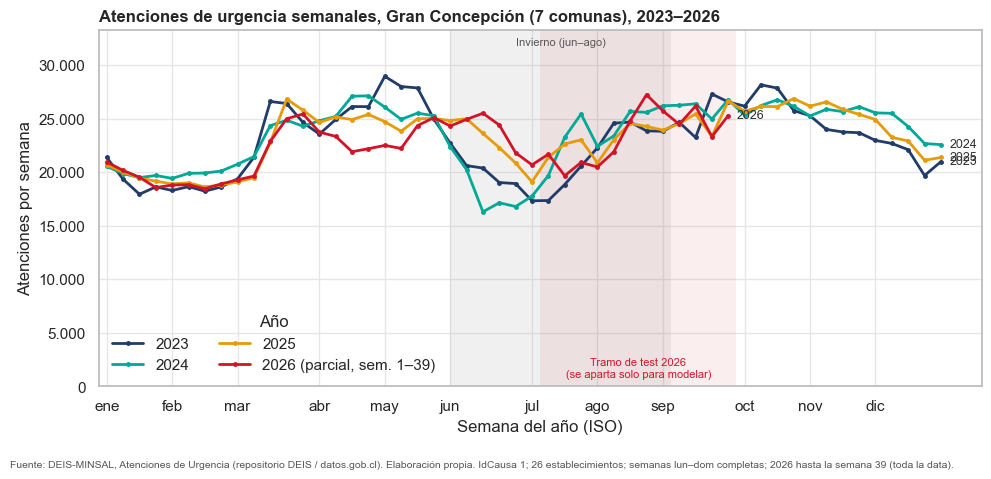

,media,semana máx.,máx.,semana mín.,mín.,índice mín. (100 = media)
año,,,,,,
2023,22886,01-05,28953,03-07,17336,76
2024,23374,22-04,27130,10-06,16306,70
2025,23255,20-10,26874,10-02,18619,80
"2026 (parcial, sem. 1–39)",22443,17-08,27242,09-02,18456,82


In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sombrear_invierno(ax)
graficar_lineas_por_anio(ax, total_semanal, "atenciones")
ax.set_ylim(0, total_semanal["atenciones"].max() * 1.15)
ax.yaxis.set_major_formatter(FuncFormatter(miles))
eje_semanas(ax)
ax.set_xlim(0.5, 54.5)   # espacio a la derecha para rotular el año
ax.set_ylabel("Atenciones por semana")
ax.set_xlabel("Semana del año (ISO)")
# Banda roja: semanas reservadas como test para el modelado (se muestran porque el EDA usa toda la data)
semana_iso_test = int(INICIO_TEST_SEMANA.isocalendar().week)
ax.axvspan(semana_iso_test - 0.5, ultima_semana_2026 + 0.5, color=RED, alpha=0.07, lw=0)
ax.text((semana_iso_test + ultima_semana_2026) / 2, 0.02, "Tramo de test 2026\n(se aparta solo para modelar)", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=8, color=RED)
ax.legend(title="Año", loc="lower left", frameon=False, ncols=2)
ax.set_title("Atenciones de urgencia semanales, Gran Concepción (7 comunas), 2023–2026", loc="left")
guardar_fig(fig, "fig1_atenciones_semanales_por_anio",
            f"IdCausa {ID_OBJETIVO}; {Y.shape[0]} establecimientos; semanas lun–dom completas; 2026 hasta la semana {ultima_semana_2026} (toda la data).")
plt.show()

# Resumen numérico de la figura: media, semana máxima y semana mínima de cada año
resumen_figura1 = []
for anio in ANIOS_EDA:
    atenciones_anio = total_semanal[total_semanal["anio_iso"] == anio]["atenciones"]
    resumen_figura1.append({"año": rotulo_anio(anio, total_semanal), "media": round(atenciones_anio.mean()),
                            "semana máx.": f"{atenciones_anio.idxmax():%d-%m}", "máx.": atenciones_anio.max(),
                            "semana mín.": f"{atenciones_anio.idxmin():%d-%m}", "mín.": atenciones_anio.min(),
                            "índice mín. (100 = media)": round(100 * atenciones_anio.min() / atenciones_anio.mean())})
display(pd.DataFrame(resumen_figura1).set_index("año"))

> **Interpretación (grupo):** _pendiente_

## 10. Figura 2 – Peso de las causas respiratorias por año

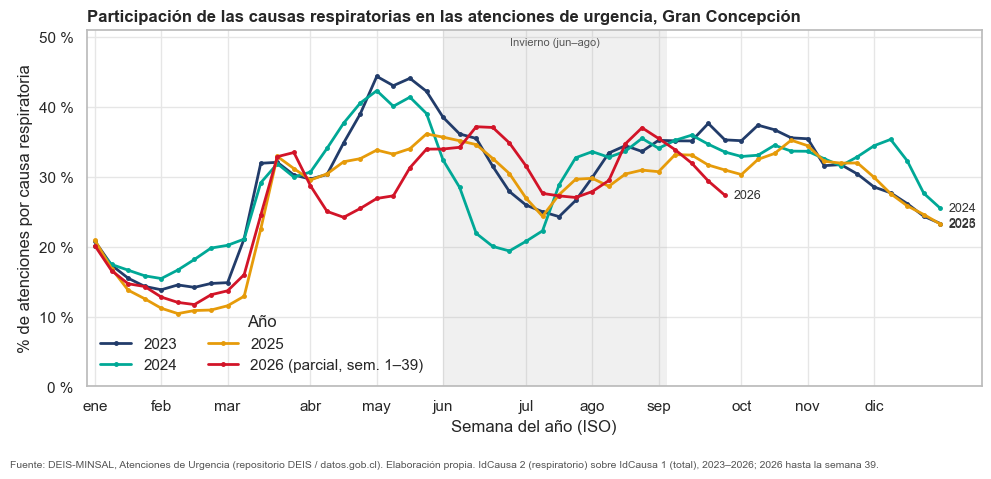

C:\Users\crizz\AppData\Local\Temp\ipykernel_5016\2428989150.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(total_semanal.groupby("anio_iso")["pct_resp"].agg(["mean", "min", "max", "idxmax"]).round(1)


,mean,min,max,semana del máx.
anio_iso,,,,
2023,29.8,13.8,44.4,2023-05-01
2024,29.5,15.4,42.3,2024-04-29
2025,27.5,10.4,36.1,2025-05-19
2026,26.6,11.7,37.2,2026-06-08


Correlación (Pearson) respiratorias vs total semanal: 0.93


In [10]:
# El subtotal respiratorio nunca debe superar al total
assert (pivote_causas[ID_RESP] <= pivote_causas[ID_OBJETIVO]).all(), "el subtotal respiratorio supera al total"
total_semanal["pct_resp"] = 100 * total_semanal["atenciones_resp"] / total_semanal["atenciones"]

fig, ax = plt.subplots(figsize=(10, 4.8))
sombrear_invierno(ax)
graficar_lineas_por_anio(ax, total_semanal, "pct_resp")
ax.set_ylim(0, total_semanal["pct_resp"].max() * 1.15)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f} %"))
eje_semanas(ax)
ax.set_xlim(0.5, 54.5)   # espacio a la derecha para rotular el año
ax.set_ylabel("% de atenciones por causa respiratoria")
ax.set_xlabel("Semana del año (ISO)")
ax.legend(title="Año", loc="lower left", frameon=False, ncols=2)
ax.set_title("Participación de las causas respiratorias en las atenciones de urgencia, Gran Concepción", loc="left")
guardar_fig(fig, "fig2_participacion_respiratoria_por_anio",
            f"IdCausa {ID_RESP} (respiratorio) sobre IdCausa {ID_OBJETIVO} (total), 2023–2026; 2026 hasta la semana {ultima_semana_2026}.")
plt.show()

display(total_semanal.groupby("anio_iso")["pct_resp"].agg(["mean", "min", "max", "idxmax"]).round(1)
           .rename(columns={"idxmax": "semana del máx."}))
print(f"Correlación (Pearson) respiratorias vs total semanal: "
      f"{total_semanal['atenciones_resp'].corr(total_semanal['atenciones']):.2f}")

> **Interpretación (grupo):** _pendiente_

## 11. Figura 3 – Establecimientos según atenciones semanales medias (2026, semanas 1–39)


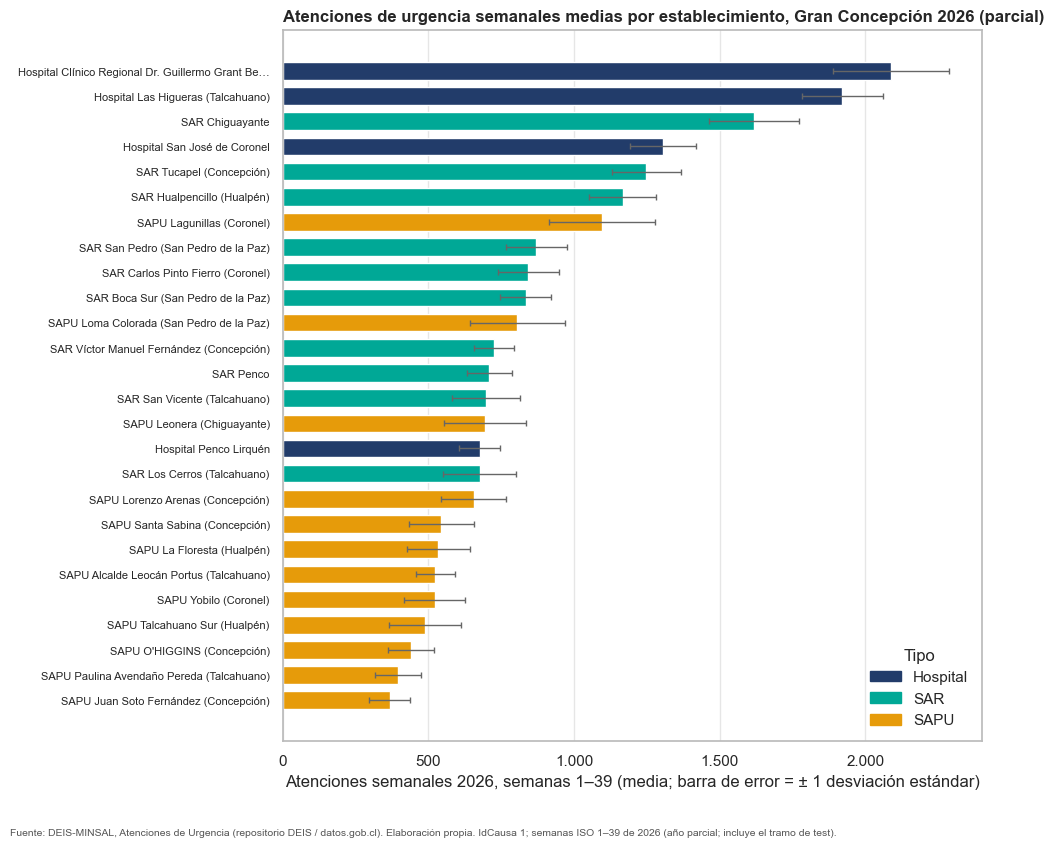

Los 5 mayores concentran el 36.5 % de las atenciones de 2026; establecimientos para llegar al 80 %: 17 de 26


In [11]:
# Media y desviación semanal de cada establecimiento en el último año (2026 es parcial: semanas ISO 1–N)
ultimo = max(ANIOS_EDA)
Y_ultimo = Y.loc[:, total_semanal.index[total_semanal["anio_iso"] == ultimo]]
ranking = Y_ultimo.agg(["mean", "std"], axis=1).join(info_est).sort_values("mean")


def etiqueta_establecimiento(nombre, comuna):
    """Nombre recortado; se agrega la comuna si el nombre no la incluye."""
    return corto(nombre, 48) + ("" if comuna in nombre else f" ({comuna})")


etiquetas = [etiqueta_establecimiento(nombre, comuna) for nombre, comuna in zip(ranking["establecimiento"], ranking["comuna"])]

fig, ax = plt.subplots(figsize=(10, 8.5))
ax.barh(etiquetas, ranking["mean"], color=[COLOR_TIPO.get(tipo, GREY) for tipo in ranking["tipo"]], height=0.7,
        xerr=ranking["std"], error_kw={"ecolor": "#666666", "elinewidth": 1, "capsize": 2})
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ax.set_xlabel(f"Atenciones semanales {ultimo}, semanas 1–{Y_ultimo.shape[1]} (media; barra de error = ± 1 desviación estándar)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
ax.legend(handles=[Patch(color=color, label=tipo) for tipo, color in COLOR_TIPO.items()],
          title="Tipo", loc="lower right", frameon=False)
ax.set_title(f"Atenciones de urgencia semanales medias por establecimiento, Gran Concepción {ultimo} (parcial)", loc="left")
guardar_fig(fig, "fig3_ranking_establecimientos",
            f"IdCausa {ID_OBJETIVO}; semanas ISO 1–{Y_ultimo.shape[1]} de {ultimo} (año parcial; incluye el tramo de test).")
plt.show()

# Concentración: qué parte de las atenciones explican los establecimientos más grandes
de_mayor_a_menor = ranking.sort_values("mean", ascending=False)
cuota_acumulada = 100 * de_mayor_a_menor["mean"].cumsum() / de_mayor_a_menor["mean"].sum()
print(f"Los 5 mayores concentran el {cuota_acumulada.iloc[4]:.1f} % de las atenciones de {ultimo}; "
      f"establecimientos para llegar al 80 %: {int((cuota_acumulada < 80).sum()) + 1} de {len(de_mayor_a_menor)}")

> **Interpretación (grupo):** _pendiente_

## 12. Figura 4 – Mapa de calor establecimiento × semana (índice 100 = media 2023–2026 del establecimiento)


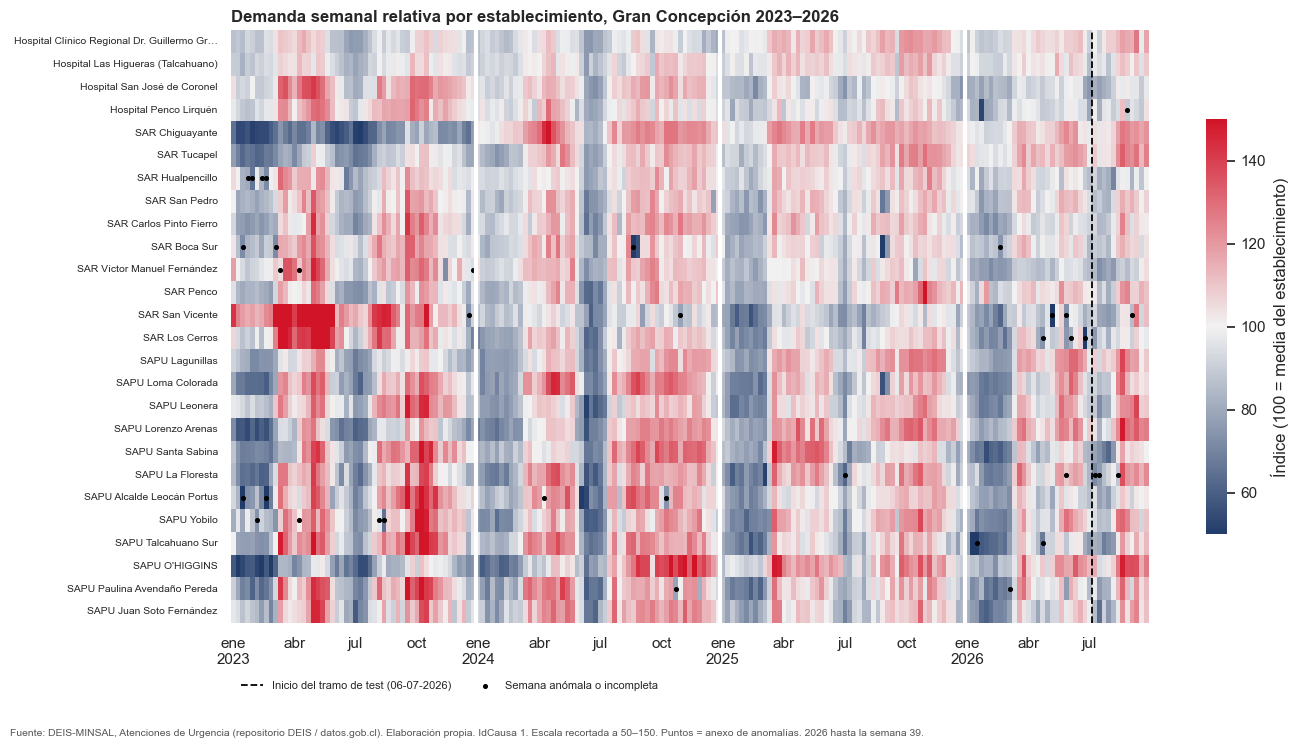

In [12]:
# Filas ordenadas por tipo (Hospital, SAR, SAPU) y, dentro de cada tipo, de mayor a menor demanda
orden_tipo = ranking["tipo"].map({tipo: k for k, tipo in enumerate(COLOR_TIPO)})
orden_filas = ranking.assign(orden_tipo=orden_tipo).sort_values(["orden_tipo", "mean"], ascending=[True, False]).index

# Índice 100 = media del establecimiento en 2023–2026 (toda la data)
indice_semanal = Y.loc[orden_filas].div(Y.loc[orden_filas].mean(axis=1), axis=0) * 100
cmap = LinearSegmentedColormap.from_list("div", [NAVY, "#f2f2f2", RED])

fig, ax = plt.subplots(figsize=(14, 7.5))
sns.heatmap(indice_semanal, cmap=cmap, vmin=50, vmax=150, center=100, ax=ax, linewidths=0,
            cbar_kws={"label": "Índice (100 = media del establecimiento)", "shrink": 0.7})

# Eje x: línea blanca al comienzo de cada año y rótulos de mes cada 13 semanas (año solo en enero)
semanas_mapa = indice_semanal.columns
calendario = total_semanal.loc[semanas_mapa, ["anio_iso", "semana_iso"]]
for k in np.where(calendario["semana_iso"].values == 1)[0][1:]:
    ax.axvline(k, color="white", lw=3)
posiciones, rotulos = [], []
for k, (anio, semana) in enumerate(zip(calendario["anio_iso"], calendario["semana_iso"])):
    if semana in (1, 14, 27, 40):
        rotulo = MESES[SEMANA_MES.index(semana)]
        if semana == 1:
            rotulo += f"\n{anio}"
        posiciones.append(k + 0.5)
        rotulos.append(rotulo)
ax.set_xticks(posiciones, rotulos, rotation=0)

# Eje y: nombre de cada establecimiento
ax.set_yticks(np.arange(len(orden_filas)) + 0.5, [corto(info_est.loc[i, "establecimiento"], 42) for i in orden_filas],
              fontsize=7.5)

# Línea punteada: inicio del tramo de test (se muestra porque el EDA usa toda la data)
ax.axvline(list(semanas_mapa).index(INICIO_TEST_SEMANA), color="black", ls="--", lw=1.3,
           label=f"Inicio del tramo de test ({INICIO_TEST_SEMANA:%d-%m-%Y})")

# Puntos negros sobre las semanas anómalas o incompletas (de la sección 7)
filas_marcadas, cols_marcadas = np.where(semana_a_marcar.loc[orden_filas, semanas_mapa].values)
ax.scatter(cols_marcadas + 0.5, filas_marcadas + 0.5, s=7, color="black", marker="o",
           label="Semana anómala o incompleta")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), frameon=False, fontsize=8, ncols=2)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Demanda semanal relativa por establecimiento, Gran Concepción 2023–2026", loc="left")
guardar_fig(fig, "fig4_heatmap_indice_semanal",
            f"IdCausa {ID_OBJETIVO}. Escala recortada a 50–150. Puntos = anexo de anomalías. 2026 hasta la semana {ultima_semana_2026}.")
plt.show()

> **Interpretación (grupo):** _pendiente_

## 13. Anexo – ¿La caída de junio–julio es solo del Gran Concepción?

Por región y año ISO: índice de atenciones de las semanas ISO 24–27 (aprox. mediados de junio a mediados de julio; 100 = media del año; 2026 es parcial, hasta la semana 39) y % respiratorio en las semanas 16–21 (abril–mayo) frente a 24–27.

In [13]:
# Totales país por región y semana (toda la data, mismas semanas que el EDA)
pais_semanal = a_semanas(pais)
pais_semanal = pais_semanal[(pais_semanal["semana_inicio"] >= semanas_eda[0])
                            & (pais_semanal["semana_inicio"] <= semanas_eda[-1])]
pais_semanal = pais_semanal.pivot_table(index=["NombreRegion", "semana_inicio"], columns="IdCausa", values="Total",
                                        aggfunc="sum").reset_index()
calendario_pais = pais_semanal["semana_inicio"].dt.isocalendar()
pais_semanal["anio_iso"], pais_semanal["semana_iso"] = calendario_pais["year"].astype(int), calendario_pais["week"].astype(int)

# Se agrega el total nacional como una "región" más
nacional = (pais_semanal.groupby(["semana_inicio", "anio_iso", "semana_iso"])[[ID_OBJETIVO, ID_RESP]].sum()
                        .reset_index())
nacional["NombreRegion"] = "PAÍS"
pais_semanal = pd.concat([pais_semanal, nacional], ignore_index=True)


def indicadores(grupo):
    """Índice de la caída de junio–julio y % respiratorio en dos ventanas, para una región y año."""
    semanas_jun_jul = grupo["semana_iso"].between(24, 27)
    semanas_abr_may = grupo["semana_iso"].between(16, 21)
    return pd.Series({
        "indice_jun_jul": 100 * grupo.loc[semanas_jun_jul, ID_OBJETIVO].mean() / grupo[ID_OBJETIVO].mean(),
        "resp_abr_may_%": 100 * grupo.loc[semanas_abr_may, ID_RESP].sum() / grupo.loc[semanas_abr_may, ID_OBJETIVO].sum(),
        "resp_jun_jul_%": 100 * grupo.loc[semanas_jun_jul, ID_RESP].sum() / grupo.loc[semanas_jun_jul, ID_OBJETIVO].sum()})


anexo_reg = (pais_semanal.groupby(["NombreRegion", "anio_iso"])[[ID_OBJETIVO, ID_RESP, "semana_iso"]]
                         .apply(indicadores).unstack("anio_iso").round(0))
anexo_reg.columns = [f"{indicador} {anio}" for indicador, anio in anexo_reg.columns]
anexo_reg = anexo_reg[[f"{indicador} {anio}" for indicador in ["indice_jun_jul", "resp_abr_may_%", "resp_jun_jul_%"]
                       for anio in ANIOS_EDA]]
guardar_tabla(anexo_reg, "anexo_caida_junio_regiones")
display(anexo_reg)

,indice_jun_jul 2023,indice_jun_jul 2024,indice_jun_jul 2025,indice_jun_jul 2026,resp_abr_may_% 2023,resp_abr_may_% 2024,resp_abr_may_% 2025,resp_abr_may_% 2026,resp_jun_jul_% 2023,resp_jun_jul_% 2024,resp_jun_jul_% 2025,resp_jun_jul_% 2026
NombreRegion,,,,,,,,,,,,
De Aisén del Gral. C. Ibáñez del Campo,92.0,87.0,102.0,110.0,28.0,33.0,23.0,23.0,31.0,22.0,30.0,30.0
De Antofagasta,92.0,99.0,105.0,111.0,42.0,40.0,34.0,31.0,35.0,34.0,35.0,37.0
De Arica y Parinacota,91.0,101.0,104.0,103.0,41.0,34.0,36.0,28.0,31.0,33.0,32.0,27.0
De Atacama,92.0,86.0,90.0,106.0,45.0,45.0,34.0,28.0,39.0,30.0,32.0,40.0
De Coquimbo,87.0,84.0,93.0,101.0,41.0,40.0,31.0,31.0,30.0,24.0,27.0,34.0
De La Araucanía,87.0,80.0,93.0,108.0,37.0,37.0,27.0,22.0,30.0,20.0,27.0,34.0
De Los Lagos,91.0,88.0,91.0,111.0,37.0,33.0,32.0,27.0,36.0,30.0,29.0,35.0
De Los Ríos,88.0,80.0,89.0,97.0,37.0,35.0,32.0,29.0,34.0,25.0,28.0,30.0
De Magallanes y de La Antártica Chilena,81.0,91.0,96.0,105.0,40.0,37.0,34.0,32.0,31.0,34.0,28.0,34.0


> **Interpretación (grupo):** _pendiente_

## 14. Anexo – Distribución por día de la semana (2023–2026, toda la data)

In [14]:
dias_sem = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

# Atenciones por día de la semana y tipo de establecimiento, como % del total de cada columna
objetivo_diario = eda[(eda["IdCausa"] == ID_OBJETIVO) & eda["IdEstablecimiento"].isin(en_series)]
objetivo_diario = objetivo_diario.assign(dia=objetivo_diario["fecha"].dt.dayofweek)
anexo_dia = objetivo_diario.pivot_table(index="dia", columns="GLOSATIPOESTABLECIMIENTO", values="Total", aggfunc="sum")
anexo_dia["Total"] = anexo_dia.sum(axis=1)
anexo_dia = (100 * anexo_dia / anexo_dia.sum()).round(1)
anexo_dia.index = dias_sem
anexo_dia.index.name = "día"
guardar_tabla(anexo_dia, "anexo_dia_semana")
display(anexo_dia)

GLOSATIPOESTABLECIMIENTO,Hospital,SAPU,SAR,Total
día,,,,
lun,16.2,15.4,14.6,15.3
mar,15.7,14.4,13.8,14.5
mié,15.3,13.6,13.6,14.0
jue,15.0,13.1,13.1,13.6
vie,14.4,12.2,12.8,13.1
sáb,11.8,14.9,15.6,14.4
dom,11.6,16.3,16.5,15.1


> **Interpretación (grupo):** _pendiente_

## 15. Tabla 4 – Dependencia temporal y relación entre bandas etarias

Autocorrelación del total semanal (todo el período, 195 semanas) (rezagos 1–8 y 52 = misma semana del año anterior) y mediana entre establecimientos; Spearman entre bandas etarias (establecimiento-semana). Justifica rezagos y variables estacionales, y advierte colinealidad.

In [15]:
rezagos = [*range(1, 9), 52]   # semanas atrás; 52 = misma semana del año anterior

# Autocorrelación del total y de cada establecimiento (se resume con la mediana)
acf_total = acf(total_semanal["atenciones"], nlags=52)
acf_por_est = pd.DataFrame({id_est: acf(serie, nlags=52, missing="drop") for id_est, serie in Y.iterrows()})
tabla4a = pd.DataFrame({"rezago_semanas": rezagos, "ACF_total_GC": acf_total[rezagos],
                        "ACF_mediana_establecimientos": acf_por_est.median(axis=1).values[rezagos]}).round(2)

# Correlación de Spearman entre bandas etarias (establecimiento-semana)
tabla4b = sem_eda[BANDAS + ["atenciones"]].corr(method="spearman").round(2)

guardar_tabla(tabla4a, "tabla4a_autocorrelacion", index=False)
guardar_tabla(tabla4b, "tabla4b_spearman_bandas")
display(tabla4a)
display(tabla4b)
print("Participación por banda etaria (%):", (100 * sem_eda[BANDAS].sum() / sem_eda["atenciones"].sum()).round(1).to_dict())

,rezago_semanas,ACF_total_GC,ACF_mediana_establecimientos
0,1,0.87,0.80
1,2,0.72,0.67
2,3,0.54,0.54
3,4,0.36,0.41
4,5,0.18,0.29
5,6,0.02,0.18
6,7,-0.12,0.05
7,8,-0.25,-0.04
8,52,0.58,0.43


,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas,atenciones
Menores_1,1.00,0.73,0.64,0.65,0.55,0.70
De_1_a_4,0.73,1.00,0.88,0.74,0.54,0.82
De_5_a_14,0.64,0.88,1.00,0.75,0.52,0.84
De_15_a_64,0.65,0.74,0.75,1.00,0.84,0.98
De_65_y_mas,0.55,0.54,0.52,0.84,1.00,0.84
atenciones,0.70,0.82,0.84,0.98,0.84,1.00


Participación por banda etaria (%): {'Menores_1': 1.9, 'De_1_a_4': 7.4, 'De_5_a_14': 16.4, 'De_15_a_64': 59.2, 'De_65_y_mas': 15.1}


> **Interpretación (grupo):** _pendiente_

## 16. Tabla 5 – Baselines (propuesta metodológica)

- **Corte cronológico:** los baselines usan solo `Y_modelo` (183 semanas, hasta el 05-07-2026). Las 12 semanas de test (desde el 06-07-2026) **no se usan aquí**: el test se gasta una sola vez, al final. Los baselines son la única etapa de modelado de este notebook; el EDA de las secciones anteriores sí cubre todo el período.
- **Validación de origen móvil:** `TimeSeriesSplit(n_splits=6, test_size=8)` sobre `Y_modelo`: 6 bloques de 8 semanas que cubren las últimas 48 semanas antes del test, cada uno validado con lo anterior.
- **Pronóstico a 1 semana** (`HORIZONTE = 1`) por establecimiento:
  - *Media del bloque de entrenamiento*: media del establecimiento en las semanas de entrenamiento (análogo a `DummyRegressor`).
  - *Última semana (naive)*: valor de la semana anterior.
  - *Media móvil 4 semanas*: promedio de las 4 semanas anteriores.
  - *Naive estacional*: valor de la misma semana del año anterior (t − 52).
- **Métricas:** MAE y RMSE en atenciones por establecimiento-semana (vistas en clase); media ± desviación entre bloques. Se agrega el **error relativo = MAE / media real** (no visto en clase) para comunicarlo al usuario del dashboard como "% de error". Cualquier modelo posterior debe superar estos valores.

**Cómo está armado el código:** cada pronóstico es una matriz del mismo tamaño que `Y_modelo` (establecimiento × semana). Para cada bloque de validación se comparan esas predicciones con los valores reales y se calculan las métricas; luego se promedian los 6 bloques.


In [16]:
semanas = Y_modelo.columns

# Pronósticos que no dependen del bloque: usan solo valores anteriores de la misma serie
pronosticos_simples = {
    "Última semana (naive)": Y_modelo.shift(HORIZONTE, axis=1),
    "Media móvil 4 semanas": Y_modelo.T.shift(HORIZONTE).rolling(4).mean().T,
    "Naive estacional (t−52)": Y_modelo.shift(52, axis=1),
}


def pronostico_media_entrenamiento(semanas_entrenamiento, semanas_validacion):
    """Dummy: a cada establecimiento se le predice su media de las semanas de entrenamiento."""
    media = Y_modelo[semanas_entrenamiento].mean(axis=1).values
    return pd.DataFrame(np.repeat(media[:, None], len(semanas_validacion), axis=1),
                        index=Y_modelo.index, columns=semanas_validacion)


# Validación de origen móvil: 6 bloques de 8 semanas, cada uno validado con lo anterior
tscv = TimeSeriesSplit(n_splits=6, test_size=8)
registros = []   # una fila por modelo y bloque (métricas)
errores = []     # un error absoluto por modelo, establecimiento y semana

for k, (i_entrenamiento, i_validacion) in enumerate(tscv.split(semanas), start=1):
    semanas_entrenamiento, semanas_validacion = semanas[i_entrenamiento], semanas[i_validacion]
    real = Y_modelo[semanas_validacion]

    pronosticos = {"Media del bloque (dummy)": pronostico_media_entrenamiento(semanas_entrenamiento, semanas_validacion)}
    pronosticos.update({nombre: pronostico[semanas_validacion] for nombre, pronostico in pronosticos_simples.items()})

    for nombre, pronostico in pronosticos.items():
        # Solo se comparan celdas donde existen tanto el valor real como el pronóstico
        ambos_validos = real.notna() & pronostico.notna()
        y_real, y_pred = real.values[ambos_validos.values], pronostico.values[ambos_validos.values]
        mae = mean_absolute_error(y_real, y_pred)
        registros.append({"modelo": nombre,
                          "bloque": f"{k}: {semanas_validacion[0]:%d-%m-%Y} a {semanas_validacion[-1]:%d-%m-%Y}",
                          "MAE": mae, "RMSE": root_mean_squared_error(y_real, y_pred),
                          "error_rel_%": 100 * mae / y_real.mean()})
        error_abs = pd.DataFrame({"error_abs": (pronostico - real).abs().stack(), "real": real.stack()})
        errores.append(error_abs.dropna().reset_index().assign(modelo=nombre))

# Tabla 5: media y desviación de las métricas entre los 6 bloques
bloques = pd.DataFrame(registros)
tabla5 = bloques.groupby("modelo", sort=False)[["MAE", "RMSE", "error_rel_%"]].agg(["mean", "std"]).round(1)
tabla5.columns = [f"{metrica}_{estadistico}" for metrica, estadistico in tabla5.columns]
tabla5 = tabla5.sort_values("MAE_mean")
guardar_tabla(tabla5, "tabla5_baselines")


def resumen_error(grupo):
    """MAE y error relativo (suma de errores / suma de reales) de un grupo de predicciones."""
    return pd.Series({"MAE": grupo["error_abs"].mean(),
                      "error_rel_%": 100 * grupo["error_abs"].sum() / grupo["real"].sum()})


# Tabla 5b: error de cada modelo por tipo de establecimiento
errores = pd.concat(errores).join(info_est["tipo"], on="IdEstablecimiento")
tabla5b = errores.groupby(["modelo", "tipo"]).apply(resumen_error).round(1).unstack("tipo")
tabla5b = tabla5b.loc[tabla5.index]
guardar_tabla(tabla5b, "tabla5b_baselines_por_tipo")

display(bloques.pivot(index="modelo", columns="bloque", values="MAE").round(1).loc[tabla5.index])
display(tabla5)
display(tabla5b)
print(f"Escala: media de atenciones por establecimiento-semana en Y_modelo (hasta {INICIO_TEST_SEMANA - pd.Timedelta(days=1):%d-%m-%Y}) = {Y_modelo.stack().mean():.1f}")

bloque,1: 04-08-2025 a 22-09-2025,2: 29-09-2025 a 17-11-2025,3: 24-11-2025 a 12-01-2026,4: 19-01-2026 a 09-03-2026,5: 16-03-2026 a 04-05-2026,6: 11-05-2026 a 29-06-2026
modelo,,,,,,
Última semana (naive),78.7,54.2,56.0,54.2,57.6,75.3
Media móvil 4 semanas,75.7,51.1,76.2,59.7,81.4,82.7
Naive estacional (t−52),97.6,87.3,82.2,58.3,97.7,81.3
Media del bloque (dummy),107.3,129.2,97.1,151.0,82.3,99.8


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,error_rel_%_mean,error_rel_%_std
modelo,,,,,,
Última semana (naive),62.7,11.2,87.7,21.5,7.1,1.1
Media móvil 4 semanas,71.1,12.8,95.0,17.8,8.1,1.5
Naive estacional (t−52),84.1,14.5,114.6,21.3,9.4,1.2
Media del bloque (dummy),111.1,24.9,142.6,26.6,12.7,3.9


MAE              error_rel_%            
tipo                     Hospital  SAPU    SAR    Hospital  SAPU   SAR
modelo                                                                
Última semana (naive)        84.3  50.5   68.6         5.5   8.3   7.1
Media móvil 4 semanas        90.7  64.4   71.4         5.9  10.6   7.4
Naive estacional (t−52)     128.5  72.8   79.9         8.3  12.0   8.2
Media del bloque (dummy)    147.0  97.6  113.0         9.5  16.0  11.7

Escala: media de atenciones por establecimiento-semana en Y_modelo (hasta 05-07-2026) = 884.5


> **Interpretación (grupo):** _pendiente_

## 16b. Primer ensayo – regresión lineal simple (exploratorio)

Primer vistazo a qué tan bien lo hace una **regresión lineal** frente a los baselines de la Tabla 5. No forma parte de la presentación de avance; es el punto de partida del modelado (rumbo: regresión lineal y XGBoost, un solo modelo global para los 26 establecimientos).

- **Una sola tabla, un modelo global:** una fila por establecimiento y semana objetivo. Variables: los últimos 1 a 4 valores del propio establecimiento (rezagos, todos anteriores a la semana que se predice), la estacionalidad anual (seno y coseno de la semana ISO) y el establecimiento (una columna por establecimiento).
- **Tres variantes, de la más simple a la más completa**, para ver qué aporta cada cosa: V1 (rezago 1 + establecimiento), V2 (+ rezagos 2 a 4) y V3 (+ estacionalidad anual).
- **Mismo `Pipeline` que usarán los demás modelos:** el escalado (`StandardScaler`) y la codificación del establecimiento (`OneHotEncoder`) van dentro del `Pipeline`, así se ajustan solo con el entrenamiento de cada bloque.
- **Misma validación y mismas métricas que los baselines:** los 6 bloques de `TimeSeriesSplit(6, test_size=8)`, pronóstico a `HORIZONTE` semanas, MAE, RMSE y error relativo (media ± desviación entre bloques). En cada bloque se entrena solo con semanas anteriores al bloque.
- **El test no se toca:** la tabla usa únicamente `Y_modelo` (hasta el 05-07-2026).
- **Cuidado al leer los coeficientes:** los rezagos están muy correlacionados entre sí (Tabla 4), así que cada coeficiente por separado no es confiable; lo que interesa es el error de predicción.

In [17]:
# --- Tabla larga: una fila por establecimiento y semana objetivo ---
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

N_REZAGOS = 4


def tabla_larga(Y):
    """Pasa Y (establecimiento × semana) a filas, con rezagos y estacionalidad.
    El rezago j de la semana t es el valor de la semana t − (HORIZONTE + j − 1): siempre anterior a lo que se predice."""
    columnas = {"y": Y}
    for j in range(1, N_REZAGOS + 1):
        columnas[f"lag_{j}"] = Y.shift(HORIZONTE + j - 1, axis=1)
    largo = pd.concat({nombre: m.stack() for nombre, m in columnas.items()}, axis=1)
    largo.index.names = ["IdEstablecimiento", "semana"]
    largo = largo.reset_index().dropna()          # se pierden las primeras semanas de cada serie (sin rezagos)
    angulo = 2 * np.pi * largo["semana"].dt.isocalendar().week.astype(float) / 52
    largo["sen_anual"], largo["cos_anual"] = np.sin(angulo), np.cos(angulo)
    return largo


largo = tabla_larga(Y_modelo)
assert largo["semana"].max() < INICIO_TEST_SEMANA, "la tabla no debe incluir semanas de test"
print(f"Tabla larga: {len(largo):,} filas, {largo['IdEstablecimiento'].nunique()} establecimientos, "
      f"semanas {largo['semana'].min():%d-%m-%Y} a {largo['semana'].max():%d-%m-%Y}")

REZAGOS = [f"lag_{j}" for j in range(1, N_REZAGOS + 1)]
VARIANTES = {
    "Lineal V1: rezago 1 + establecimiento": ["lag_1"],
    "Lineal V2: + rezagos 2 a 4": REZAGOS,
    "Lineal V3: + estacionalidad anual": REZAGOS + ["sen_anual", "cos_anual"],
}


def pipeline_lineal(variables_numericas):
    """Escalado de lo numérico y una columna por establecimiento, dentro del Pipeline (se ajustan con el entrenamiento)."""
    previo = ColumnTransformer([("num", StandardScaler(), variables_numericas),
                                ("est", OneHotEncoder(handle_unknown="ignore"), ["IdEstablecimiento"])])
    return Pipeline([("previo", previo), ("lineal", LinearRegression())])


# --- Validación de origen móvil: los mismos 6 bloques de 8 semanas de la Tabla 5 ---
registros_lineal = []
for k, (i_entrenamiento, i_validacion) in enumerate(tscv.split(semanas), start=1):
    semanas_entrenamiento, semanas_validacion = semanas[i_entrenamiento], semanas[i_validacion]
    entrenamiento = largo[largo["semana"].isin(semanas_entrenamiento)]
    validacion = largo[largo["semana"].isin(semanas_validacion)]
    assert len(validacion) == Y_modelo.shape[0] * len(semanas_validacion), "deben estar las mismas celdas que en los baselines"
    for nombre, variables in VARIANTES.items():
        modelo = pipeline_lineal(variables).fit(entrenamiento[variables + ["IdEstablecimiento"]], entrenamiento["y"])
        prediccion = modelo.predict(validacion[variables + ["IdEstablecimiento"]])
        mae = mean_absolute_error(validacion["y"], prediccion)
        registros_lineal.append({"modelo": nombre, "MAE": mae,
                                 "RMSE": root_mean_squared_error(validacion["y"], prediccion),
                                 "error_rel_%": 100 * mae / validacion["y"].mean()})

tabla_lineal = pd.DataFrame(registros_lineal).groupby("modelo", sort=False)[["MAE", "RMSE", "error_rel_%"]].agg(["mean", "std"]).round(1)
tabla_lineal.columns = [f"{metrica}_{estadistico}" for metrica, estadistico in tabla_lineal.columns]

# Tabla 6: los tres ensayos lineales junto a los baselines de la Tabla 5 (mismos bloques, mismas métricas)
tabla6 = pd.concat([tabla5, tabla_lineal]).sort_values("MAE_mean")
guardar_tabla(tabla6, "tabla6_regresion_lineal")
display(tabla6)

Tabla larga: 4,654 filas, 26 establecimientos, semanas 30-01-2023 a 29-06-2026


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,error_rel_%_mean,error_rel_%_std
modelo,,,,,,
Lineal V3: + estacionalidad anual,59.3,9.6,82.7,19.4,6.7,1.0
Lineal V2: + rezagos 2 a 4,59.8,9.1,83.0,19.2,6.7,1.0
Lineal V1: rezago 1 + establecimiento,60.5,9.5,83.8,19.5,6.8,1.0
Última semana (naive),62.7,11.2,87.7,21.5,7.1,1.1
Media móvil 4 semanas,71.1,12.8,95.0,17.8,8.1,1.5
Naive estacional (t−52),84.1,14.5,114.6,21.3,9.4,1.2
Media del bloque (dummy),111.1,24.9,142.6,26.6,12.7,3.9


In [18]:
# Coeficientes estandarizados de la mejor variante lineal (ajustada con todo Y_modelo; herramienta de clase: coef_)
mejor = tabla_lineal["MAE_mean"].idxmin()
variables = VARIANTES[mejor]
modelo_final = pipeline_lineal(variables).fit(largo[variables + ["IdEstablecimiento"]], largo["y"])
nombres = modelo_final.named_steps["previo"].get_feature_names_out()
coeficientes = pd.Series(modelo_final.named_steps["lineal"].coef_, index=nombres)
numericos = coeficientes[[n.startswith("num__") for n in nombres]].rename(lambda n: n.replace("num__", ""))
print(f"Mejor variante lineal por MAE medio: {mejor}")
print("Coeficientes de las variables numéricas (atenciones por cada desviación estándar):")
print(numericos.round(1).sort_values(key=np.abs, ascending=False).to_string())

Mejor variante lineal por MAE medio: Lineal V3: + estacionalidad anual
Coeficientes de las variables numéricas (atenciones por cada desviación estándar):
lag_1        341.2
lag_2         48.9
lag_4        -22.7
lag_3          8.6
cos_anual     -4.0
sen_anual     -3.2


> **Interpretación (grupo):** _pendiente_

## 17. Exportación

- `data/processed/urgencias_gc_diario.parquet`: extracto filtrado diario 2023–2026 (formato largo, todas las causas).
- `data/processed/urgencias_pais_region_diario.parquet`: total país por región y día (causas 1 y 2).
- `data/processed/urgencias_gc_semanal.parquet`: serie semanal por establecimiento, con la columna `conjunto` (`entrenamiento` / `test`; el EDA usa ambos).
- `data/processed/perfil_archivos.csv`: filas y causas por archivo anual.
- `resultados/tablas/*.csv` y `resultados/figuras/*.png`.

In [19]:
sem.to_parquet(DIR_PROC / "urgencias_gc_semanal.parquet", index=False)
for carpeta in (DIR_PROC, DIR_TAB, DIR_FIG):
    for archivo in sorted(carpeta.iterdir()):
        print(f"{archivo}  ({archivo.stat().st_size / 1024:,.0f} KB)")

data\processed\perfil_archivos.csv  (1 KB)
data\processed\urgencias_gc_diario.parquet  (4,039 KB)
data\processed\urgencias_gc_semanal.parquet  (72 KB)
data\processed\urgencias_pais_region_diario.parquet  (173 KB)
resultados\tablas\anexo_caida_junio_regiones.csv  (2 KB)
resultados\tablas\anexo_causas.csv  (3 KB)
resultados\tablas\anexo_dia_semana.csv  (0 KB)
resultados\tablas\anexo_dias_objetivo_cero.csv  (2 KB)
resultados\tablas\anexo_semanas_anomalas.csv  (3 KB)
resultados\tablas\tabla1_descripcion_datos.csv  (1 KB)
resultados\tablas\tabla1b_establecimientos_por_anio.csv  (2 KB)
resultados\tablas\tabla2_calidad_datos.csv  (2 KB)
resultados\tablas\tabla3_estadistica_objetivo.csv  (1 KB)
resultados\tablas\tabla3b_media_semanal_establecimiento.csv  (2 KB)
resultados\tablas\tabla4a_autocorrelacion.csv  (0 KB)
resultados\tablas\tabla4b_spearman_bandas.csv  (0 KB)
resultados\tablas\tabla5_baselines.csv  (0 KB)
resultados\tablas\tabla5b_baselines_por_tipo.csv  (0 KB)
resultados\tablas\tabla6

## 18. Preguntas abiertas para los profesores

1. **Comunas:** ¿solo las 7 comunas núcleo (Concepción, Talcahuano, Hualpén, San Pedro de la Paz, Chiguayante, Penco, Coronel) o también Tomé, Lota, Hualqui, Florida y Santa Juana?
2. **Horizonte del pronóstico:** ¿1 semana, 4 semanas u otro? Depende de con cuánta anticipación se programan los turnos.
3. **De atenciones a demanda médica:** DEIS publica atenciones, no dotación. ¿Se acepta una regla (atenciones por médico-turno) o se espera otra fuente?
4. **Variable objetivo:** ¿IdCausa 1 (total atenciones de urgencia) o 34 (total demanda)? El diccionario del DEIS solo da los nombres; no coinciden y la jerarquía de causas no cierra (Tabla 2).
5. **Diseño temporal:** el EDA usa toda la data (2023–2026) y el test son las últimas 12 semanas (06-07 a 27-09-2026), que solo se apartan para el modelado. ¿Se acepta, dado que en clase se describe solo el *train* antes de modelar? ¿Y validar con `TimeSeriesSplit` en vez de K-fold aleatorio (en clase solo se vio K-fold)? ¿Son 12 semanas un test razonable aunque no incluya el pico de invierno completo?
6. **Caída de junio–julio:** aparece en varias regiones y años (anexo regional). ¿Se trata como fenómeno real (estacionalidad) o como problema de registro?
7. **Anomalías:** ¿excluir, imputar o mantener las semanas anómalas al entrenar?
8. **Métrica:** ¿se puede reportar el error relativo (MAE / media) además de MAE y RMSE?
9. **Datos versionados:** ¿basta con versionar el extracto filtrado (`data/processed/`) y el manifiesto con SHA-256 de los crudos?
10. **Uso de IA:** ¿rige la regla del Control 2 (IA solo para código, no para análisis ni interpretación)?
11. **Alcance temporal:** ¿alcanza con 2023–2026 o conviene sumar 2017–2022 (la base DEIS parte en 2017; 2020–2021 estarían afectados por la pandemia)?
